In [38]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [39]:
# Cell 2: Load and parse
df = pd.read_csv(r'..\Data\Raw\network_traffic.csv', parse_dates=['time'])

# Sort by time and reset index
df = df.sort_values('time').reset_index(drop=True)

# Quick peek
print("Shape:", df.shape)
df.head()

Shape: (10005, 12)


,time,source_ip_int,destination_ip_int,source_port,destination_port,protocol,duration,packet_count,bytes_sent,bytes_received,label,bytes_per_packet
0,2025-04-06 20:10:13,755769912,3232235777,12345,80,0,0.050000,15000,250000,1200,1,16.666667
1,2025-04-06 20:10:13,3232279686,167807963,34158,143,0,3.547668,14,3259,8139,0,232.785714
2,2025-04-06 20:10:18,3232249985,167807780,25374,46026,0,0.010783,2,41,89,1,20.500000
3,2025-04-06 20:10:23,3232298001,167818478,51916,23,1,3.455080,39,2267,10456,0,58.128205
4,2025-04-06 20:10:28,3232291304,167815432,37340,37260,0,0.099917,3,74,54,1,24.666667


In [40]:
# Cell 3: Descriptive statistics
df.describe()

,time,source_ip_int,destination_ip_int,source_port,destination_port,protocol,duration,packet_count,bytes_sent,bytes_received,label,bytes_per_packet
count,10005,1.000500e+04,1.000500e+04,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.000000,10005.00000,10005.000000
mean,2025-04-07 05:36:32.310345,3.231715e+09,1.693629e+08,33548.602599,5321.814393,0.461769,3.803535,275.166217,28982.593103,6791.777811,0.20040,227.817587
min,2025-04-06 20:10:13,1.684301e+08,1.677724e+08,1031.000000,22.000000,0.000000,0.010000,1.000000,40.000000,40.000000,0.00000,1.105263
25%,2025-04-06 23:38:13,3.232252e+09,1.677884e+08,17318.000000,25.000000,0.000000,1.067467,27.000000,2225.000000,2330.000000,0.00000,42.000000
50%,2025-04-07 04:29:43,3.232268e+09,1.678047e+08,33652.000000,110.000000,0.000000,2.432208,54.000000,5311.000000,6407.000000,0.00000,91.179104
75%,2025-04-07 11:26:33,3.232285e+09,1.678212e+08,49910.000000,993.000000,1.000000,3.931768,82.000000,8308.000000,10850.000000,0.00000,177.080000
max,2025-04-07 18:23:23,3.232301e+09,3.405804e+09,65528.000000,65427.000000,5.000000,59.770563,15000.000000,999323.000000,19925.000000,1.00000,8440.542373
std,NaN,3.938386e+07,6.970124e+07,18731.288377,14808.430925,0.908808,7.399396,1173.655594,119121.191880,4766.473452,0.40032,531.940607


In [41]:
# Cell 4: Value counts on categorical / discrete columns
print("Label distribution:")
print(df['label'].value_counts(), "\n")

print("Protocol distribution:")
print(df['protocol'].value_counts(), "\n")

print("Destination port top 10:")
print(df['destination_port'].value_counts().head(10))

Label distribution:
label
0    8000
1    2005
Name: count, dtype: int64 

Protocol distribution:
protocol
0    6981
1    2211
2     416
4     140
3     134
5     123
Name: count, dtype: int64 

Destination port top 10:
destination_port
23     973
443    973
80     906
22     898
25     839
995    818
993    812
53     794
110    782
143    732
Name: count, dtype: int64


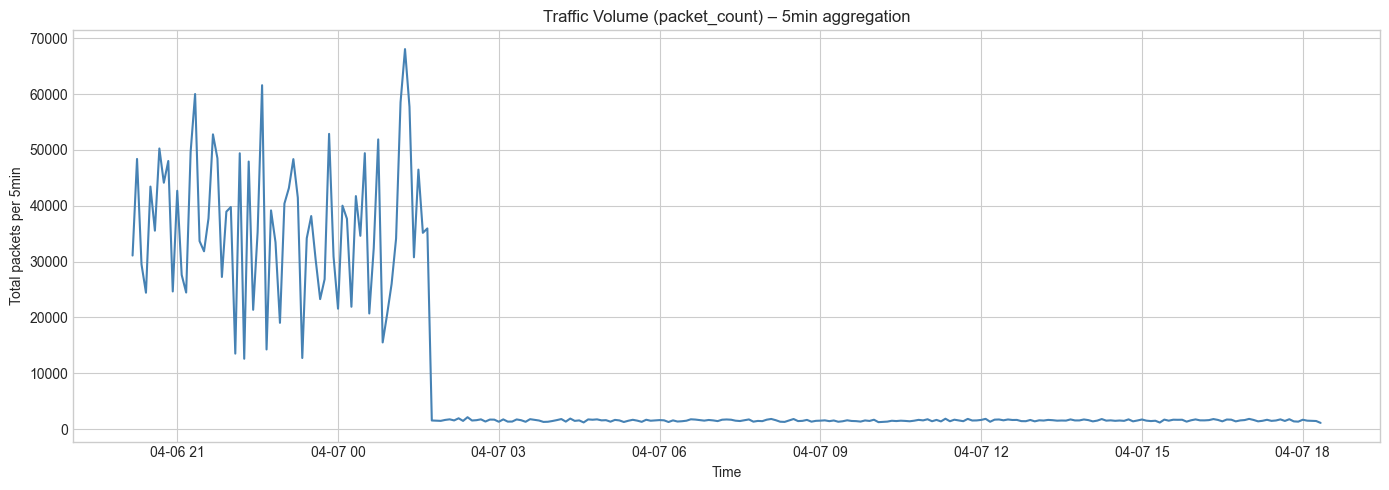

In [42]:
# Cell 5: Traffic volume (packet_count) resampled to 5min
traffic_5min = df.set_index('time').resample('5min')['packet_count'].sum()

plt.figure(figsize=(14,5))
plt.plot(traffic_5min.index, traffic_5min.values, color='steelblue')
plt.title('Traffic Volume (packet_count) – 5min aggregation')
plt.xlabel('Time')
plt.ylabel('Total packets per 5min')
plt.tight_layout()
plt.show()

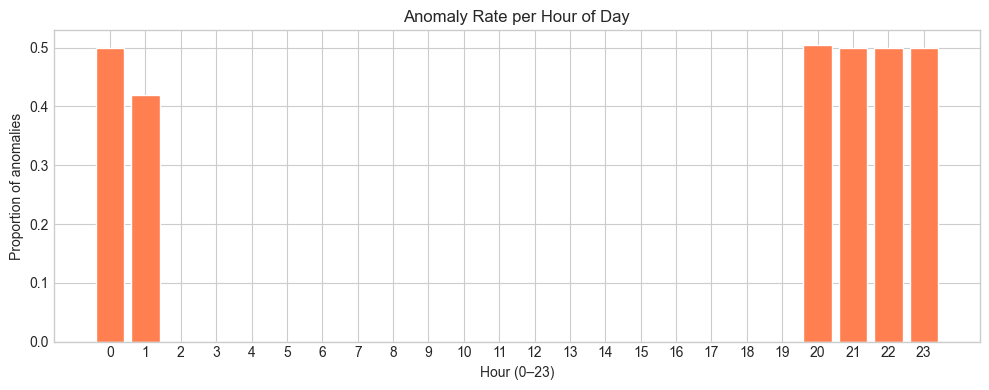

In [43]:
# Cell 6: Anomaly rate per hour
df['hour'] = df['time'].dt.hour
anomaly_rate_hour = df.groupby('hour')['label'].mean()

plt.figure(figsize=(10,4))
plt.bar(anomaly_rate_hour.index, anomaly_rate_hour.values, color='coral')
plt.title('Anomaly Rate per Hour of Day')
plt.xlabel('Hour (0–23)')
plt.ylabel('Proportion of anomalies')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

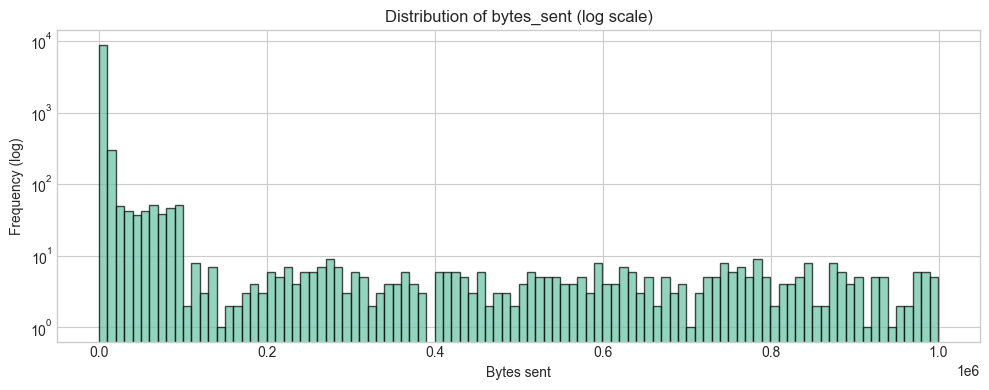

In [44]:
# Cell 7: Histogram of bytes_sent (log scale)
plt.figure(figsize=(10,4))
plt.hist(df['bytes_sent'], bins=100, log=True, edgecolor='black', alpha=0.7)
plt.title('Distribution of bytes_sent (log scale)')
plt.xlabel('Bytes sent')
plt.ylabel('Frequency (log)')
plt.tight_layout()
plt.show()

C:\Users\Arosha IIT\AppData\Local\Temp\ipykernel_6344\3785038526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='bytes_sent', data=df, palette='Set2')


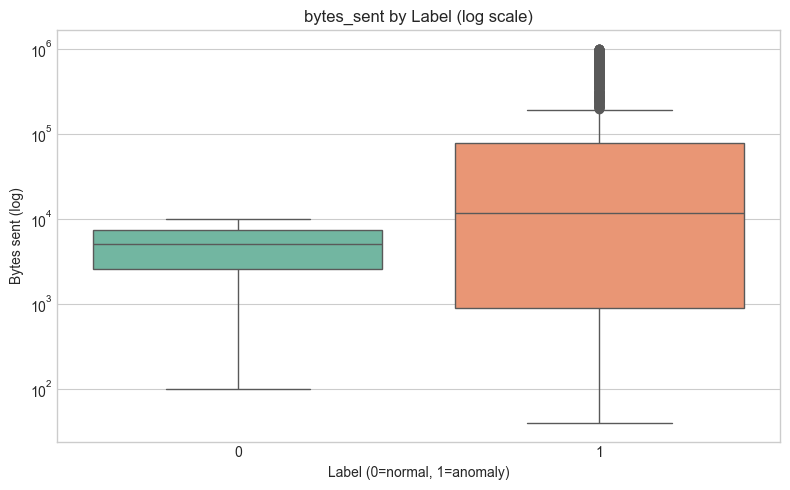

In [45]:
# Cell 8: Box plot of bytes_sent split by label
plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='bytes_sent', data=df, palette='Set2')
plt.yscale('log')
plt.title('bytes_sent by Label (log scale)')
plt.xlabel('Label (0=normal, 1=anomaly)')
plt.ylabel('Bytes sent (log)')
plt.tight_layout()
plt.show()

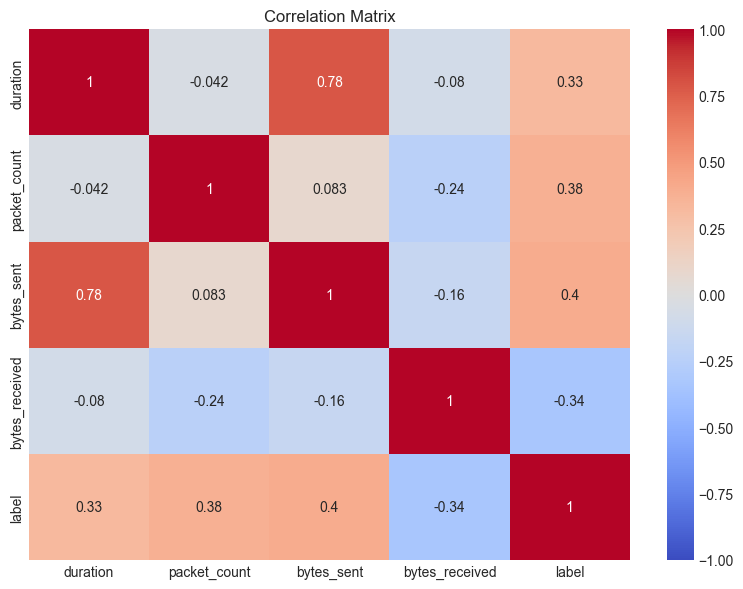

In [46]:
# Cell 9: Correlation heatmap
numeric_cols = ['duration', 'packet_count', 'bytes_sent', 'bytes_received', 'label']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

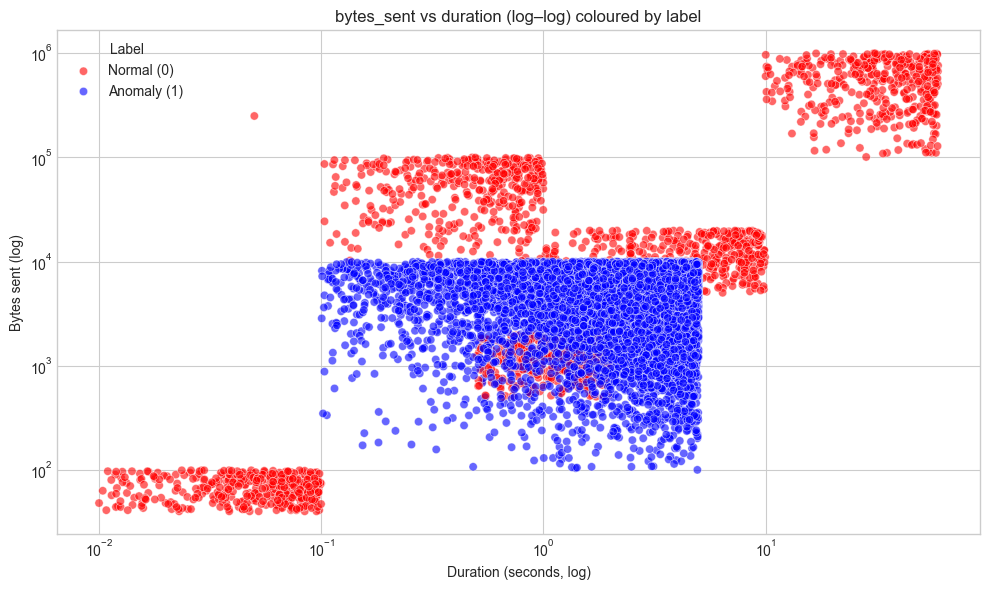

In [47]:
# Cell 10: Scatter plot – bytes_sent vs duration coloured by label
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='duration', y='bytes_sent', hue='label', alpha=0.6, palette={0:'blue', 1:'red'})
plt.xscale('log')
plt.yscale('log')
plt.title('bytes_sent vs duration (log–log) coloured by label')
plt.xlabel('Duration (seconds, log)')
plt.ylabel('Bytes sent (log)')
plt.legend(title='Label', labels=['Normal (0)', 'Anomaly (1)'])
plt.tight_layout()
plt.show()

In [48]:
# Cell 11: Filter only anomalies
anomalies = df[df['label'] == 1].copy()
print(f"Total anomalies: {len(anomalies)} ({len(anomalies)/len(df)*100:.2f}% of data)")

Total anomalies: 2005 (20.04% of data)


In [49]:
# Cell 12: Anomaly – destination port analysis
print("Top 10 destination ports in anomalies:")
print(anomalies['destination_port'].value_counts().head(10))

# Telnet port 23 check
telnet_anomalies = anomalies[anomalies['destination_port'] == 23]
print(f"\nNumber of anomalies on port 23 (Telnet): {len(telnet_anomalies)}")

Top 10 destination ports in anomalies:
destination_port
3389     149
443      145
80       137
22       126
8080     119
23       119
59111      2
54321      2
61124      2
49848      2
Name: count, dtype: int64

Number of anomalies on port 23 (Telnet): 119


In [50]:
# Cell 13: Anomaly – protocol analysis
print("Protocol distribution in anomalies:")
print(anomalies['protocol'].value_counts(normalize=True) * 100)

Protocol distribution in anomalies:
protocol
0    69.875312
1    10.324190
4     6.982544
3     6.683292
5     6.134663
Name: proportion, dtype: float64


In [51]:
# Cell 14: Anomaly – source IPs (top attackers)
print("Top 10 source IPs (integer representation) generating anomalies:")
print(anomalies['source_ip_int'].value_counts().head(10))

# Optional: convert back to dotted decimal if needed
def int_to_ip(int_ip):
    return '.'.join(str((int_ip >> (8*i)) & 0xFF) for i in reversed(range(4)))

print("\nTop 3 source IPs in readable format:")
for ip_int in anomalies['source_ip_int'].value_counts().head(3).index:
    print(f"  {int_to_ip(ip_int)}")

Top 10 source IPs (integer representation) generating anomalies:
source_ip_int
3232298307    3
3232253454    3
3232298603    2
3232276758    2
3232235801    2
3232279729    2
3232289253    2
3232246717    2
3232254082    2
3232260884    2
Name: count, dtype: int64

Top 3 source IPs in readable format:
  192.168.245.67
  192.168.70.14
  192.168.246.107
